# Import & Load Data

In [ ]:
# =========================================================
# 1) Upload file (NO Google Drive mount)
# =========================================================
from google.colab import files
uploaded = files.upload()   # เลือกไฟล์ train.xlsx

# =========================================================
# 2) Import libraries
# =========================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set(style="whitegrid")



Saving train.xlsx to train.xlsx


# EDA-Distribution

Dataset shape: (381109, 12)
   id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0   1    Male   44                1           28                   0   
1   2    Male   76                1            3                   0   
2   3    Male   47                1           28                   0   
3   4    Male   21                1           11                   1   
4   5  Female   29                1           41                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  \
0   > 2 Years            Yes           40454                    26      217   
1    1-2 Year             No           33536                    26      183   
2   > 2 Years            Yes           38294                    26       27   
3    < 1 Year             No           28619                   152      203   
4    < 1 Year             No           27496                   152       39   

   Response  
0         1  
1         0  
2         1  
3       

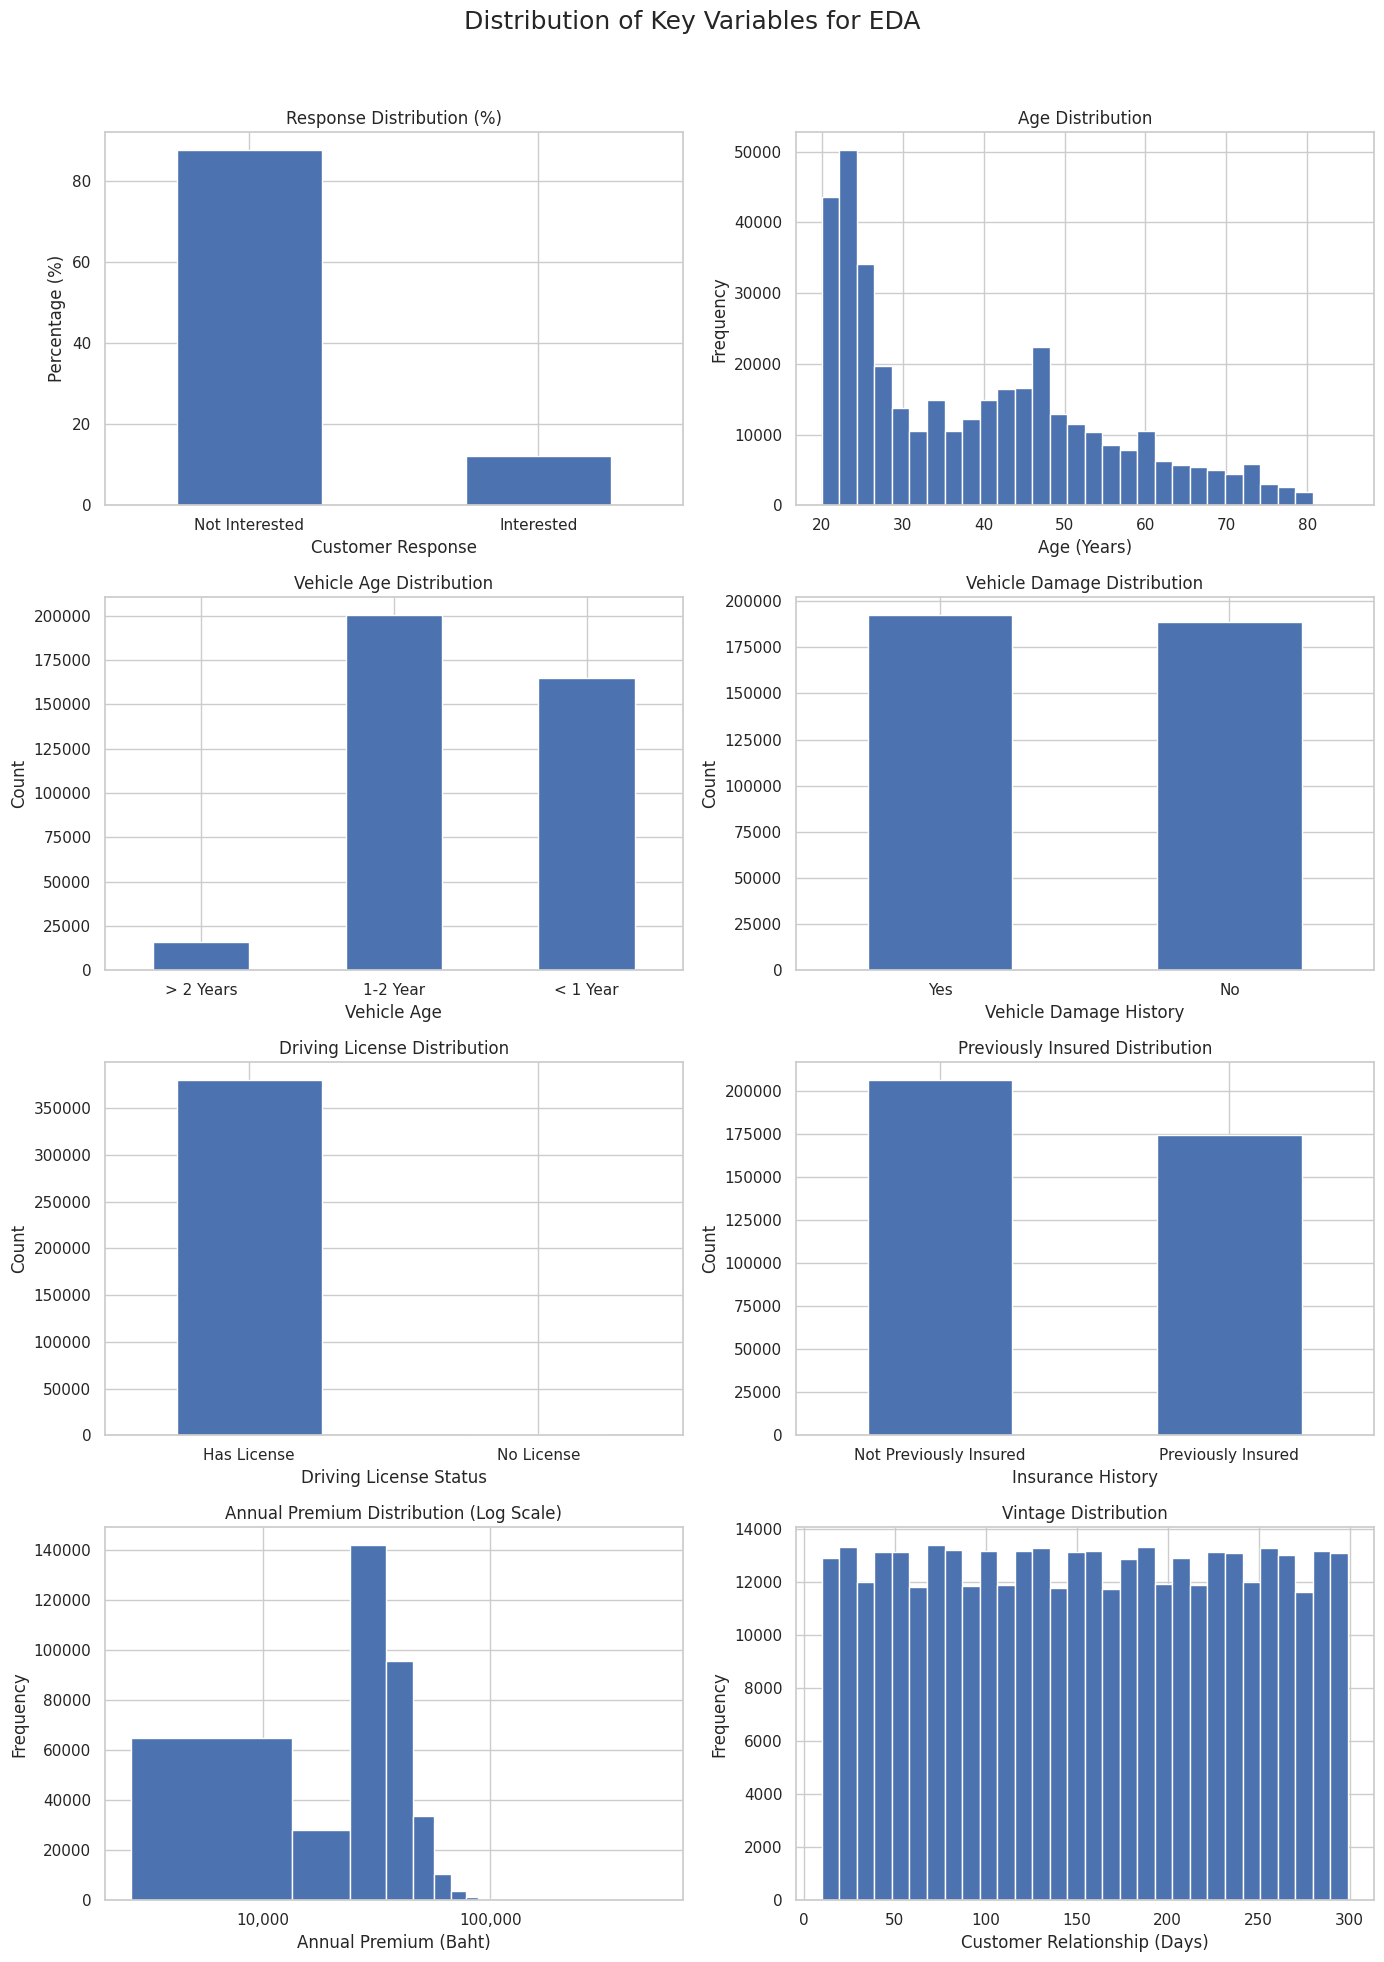

✅ Figure saved as: eda_key_distributions_with_binary_rot180.png


In [ ]:
# =========================================================
# 3) Load dataset
# =========================================================
df = pd.read_excel("train.xlsx")

print("Dataset shape:", df.shape)
print(df.head())

# =========================================================
# 4) Create distribution plots
# =========================================================
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle("Distribution of Key Variables for EDA", fontsize=18)

# -------------------------
# Response Distribution (%)
# -------------------------
response_pct = df["Response"].value_counts(normalize=True) * 100
response_pct = response_pct.rename({0: "Not Interested", 1: "Interested"})
response_pct = response_pct.reindex(["Not Interested", "Interested"])

response_pct.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Response Distribution (%)")
axes[0, 0].set_xlabel("Customer Response")
axes[0, 0].set_ylabel("Percentage (%)")

# -------------------------
# Age Distribution
# -------------------------
axes[0, 1].hist(df["Age"], bins=30)
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age (Years)")
axes[0, 1].set_ylabel("Frequency")

# -------------------------
# Vehicle Age Distribution (Old → New)
# -------------------------
vehicle_age_order = ["> 2 Years", "1-2 Year", "< 1 Year"]
df["Vehicle_Age"].value_counts().reindex(vehicle_age_order).plot(
    kind="bar", ax=axes[1, 0]
)
axes[1, 0].set_title("Vehicle Age Distribution")
axes[1, 0].set_xlabel("Vehicle Age")
axes[1, 0].set_ylabel("Count")

# -------------------------
# Vehicle Damage Distribution
# -------------------------
damage_order = ["Yes", "No"]
df["Vehicle_Damage"].value_counts().reindex(damage_order).plot(
    kind="bar", ax=axes[1, 1]
)
axes[1, 1].set_title("Vehicle Damage Distribution")
axes[1, 1].set_xlabel("Vehicle Damage History")
axes[1, 1].set_ylabel("Count")

# -------------------------
# Driving License Distribution
# -------------------------
license_map = {1: "Has License", 0: "No License"}
df["Driving_License"].map(license_map).value_counts().plot(
    kind="bar", ax=axes[2, 0]
)
axes[2, 0].set_title("Driving License Distribution")
axes[2, 0].set_xlabel("Driving License Status")
axes[2, 0].set_ylabel("Count")

# -------------------------
# Previously Insured Distribution
# -------------------------
insured_map = {1: "Previously Insured", 0: "Not Previously Insured"}
df["Previously_Insured"].map(insured_map).value_counts().plot(
    kind="bar", ax=axes[2, 1]
)
axes[2, 1].set_title("Previously Insured Distribution")
axes[2, 1].set_xlabel("Insurance History")
axes[2, 1].set_ylabel("Count")

# -------------------------
# Annual Premium (Log Scale)
# -------------------------
axes[3, 0].hist(df["Annual_Premium"], bins=50)
axes[3, 0].set_xscale("log")
axes[3, 0].set_title("Annual Premium Distribution (Log Scale)")
axes[3, 0].set_xlabel("Annual Premium (Baht)")
axes[3, 0].set_ylabel("Frequency")
axes[3, 0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}")
)

# -------------------------
# Vintage Distribution
# -------------------------
axes[3, 1].hist(df["Vintage"], bins=30)
axes[3, 1].set_title("Vintage Distribution")
axes[3, 1].set_xlabel("Customer Relationship (Days)")
axes[3, 1].set_ylabel("Frequency")

# -------------------------
# Rotate X-axis labels 180 degrees
# -------------------------
for ax in axes.flatten():
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# =========================================================
# 5) Save figure for report / thesis
# =========================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(
    "eda_key_distributions_with_binary_rot180.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Figure saved as: eda_key_distributions_with_binary_rot180.png")

# EDA-Categorical vs Response

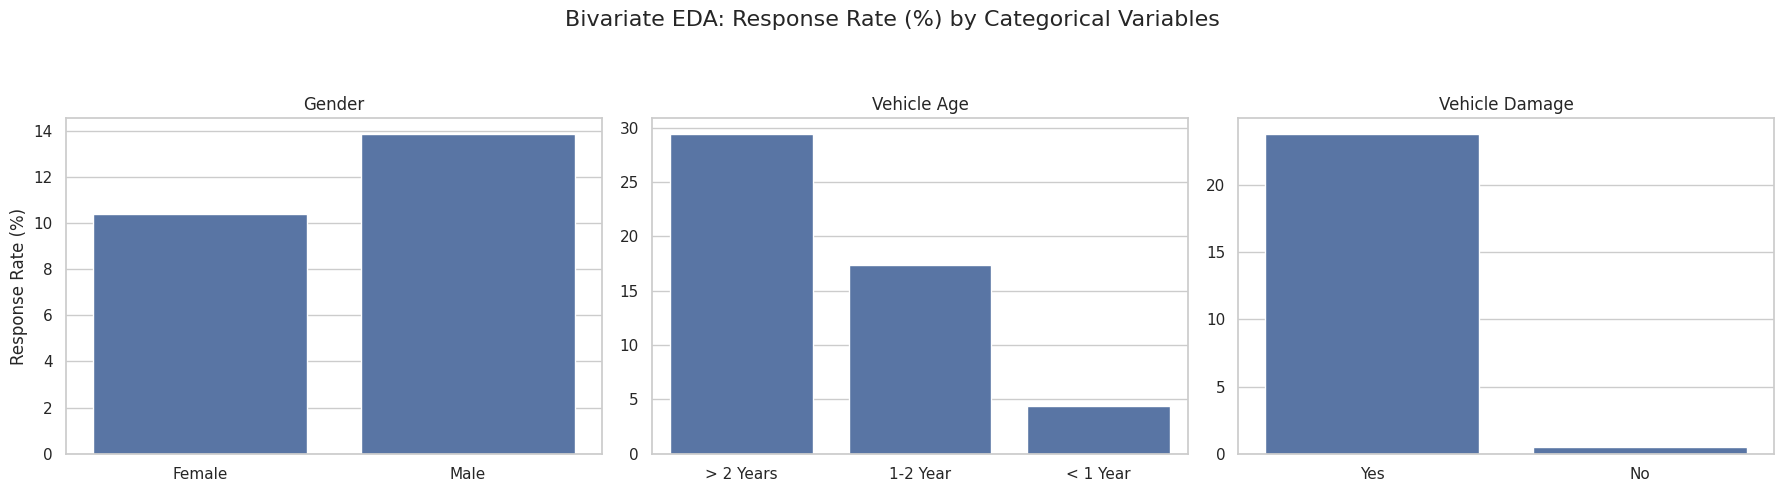

✅ Saved: eda_bivariate_categorical_response_rate.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# โหลดข้อมูล
df = pd.read_excel("train.xlsx")

# ฟังก์ชันคำนวณ response rate
def response_rate(df, col):
    return (
        df.groupby(col)["Response"]
        .mean()
        .mul(100)
        .reset_index(name="Response Rate (%)")
    )

# เตรียม figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Bivariate EDA: Response Rate (%) by Categorical Variables",
    fontsize=16
)

# 1. Gender
sns.barplot(
    data=response_rate(df, "Gender"),
    x="Gender",
    y="Response Rate (%)",
    ax=axes[0]
)
axes[0].set_title("Gender")
axes[0].set_xlabel("")
axes[0].set_ylabel("Response Rate (%)")

# 2. Vehicle Age (เรียงจากรถเก่า → รถใหม่)
vehicle_age_order = ["> 2 Years", "1-2 Year", "< 1 Year"]

sns.barplot(
    data=response_rate(df, "Vehicle_Age"),
    x="Vehicle_Age",
    y="Response Rate (%)",
    order=vehicle_age_order,
    ax=axes[1]
)
axes[1].set_title("Vehicle Age")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# 3. Vehicle Damage
sns.barplot(
    data=response_rate(df, "Vehicle_Damage"),
    x="Vehicle_Damage",
    y="Response Rate (%)",
    order=["Yes", "No"],
    ax=axes[2]
)
axes[2].set_title("Vehicle Damage")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

# จัด layout + save
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(
    "eda_bivariate_categorical_response_rate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Saved: eda_bivariate_categorical_response_rate.png")

# EDA-Binary vs Response

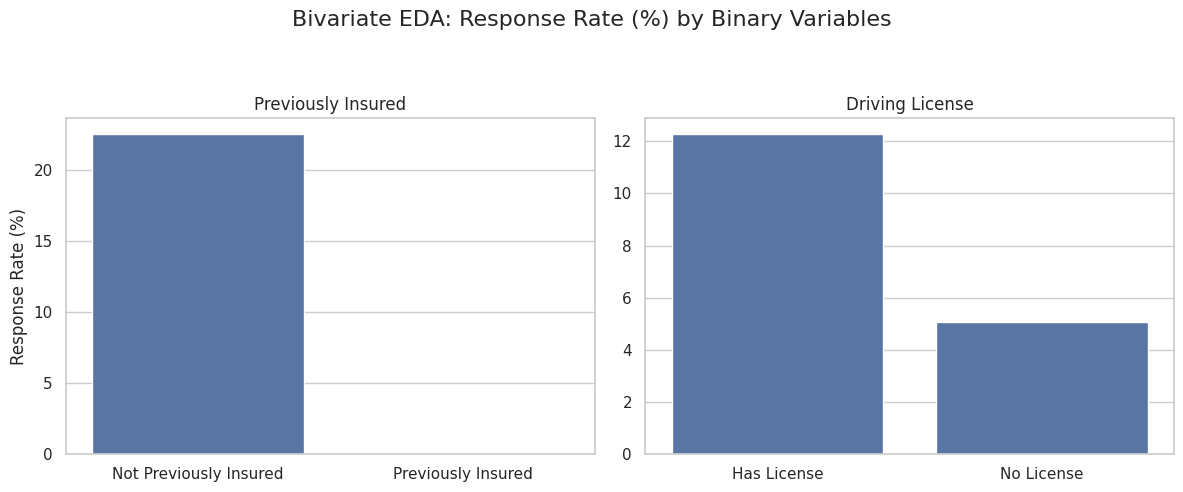

✅ Saved: eda_bivariate_binary_response_rate.png


In [ ]:
# ===============================
# Binary Variables vs Response
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_excel("train.xlsx")

# Create readable labels
df["Previously_Insured_Label"] = df["Previously_Insured"].map({
    1: "Previously Insured",
    0: "Not Previously Insured"
})

df["Driving_License_Label"] = df["Driving_License"].map({
    1: "Has License",
    0: "No License"
})

# Response rate function
def response_rate(df, col):
    return (
        df.groupby(col)["Response"]
        .mean()
        .mul(100)
        .reset_index(name="Response Rate (%)")
    )

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Bivariate EDA: Response Rate (%) by Binary Variables",
    fontsize=16
)

# Previously Insured
sns.barplot(
    data=response_rate(df, "Previously_Insured_Label"),
    x="Previously_Insured_Label",
    y="Response Rate (%)",
    ax=axes[0]
)
axes[0].set_title("Previously Insured")
axes[0].set_xlabel("")
axes[0].set_ylabel("Response Rate (%)")

# Driving License
sns.barplot(
    data=response_rate(df, "Driving_License_Label"),
    x="Driving_License_Label",
    y="Response Rate (%)",
    ax=axes[1]
)
axes[1].set_title("Driving License")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Layout & save
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(
    "eda_bivariate_binary_response_rate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Saved: eda_bivariate_binary_response_rate.png")

# EDA-Numerical vs Response

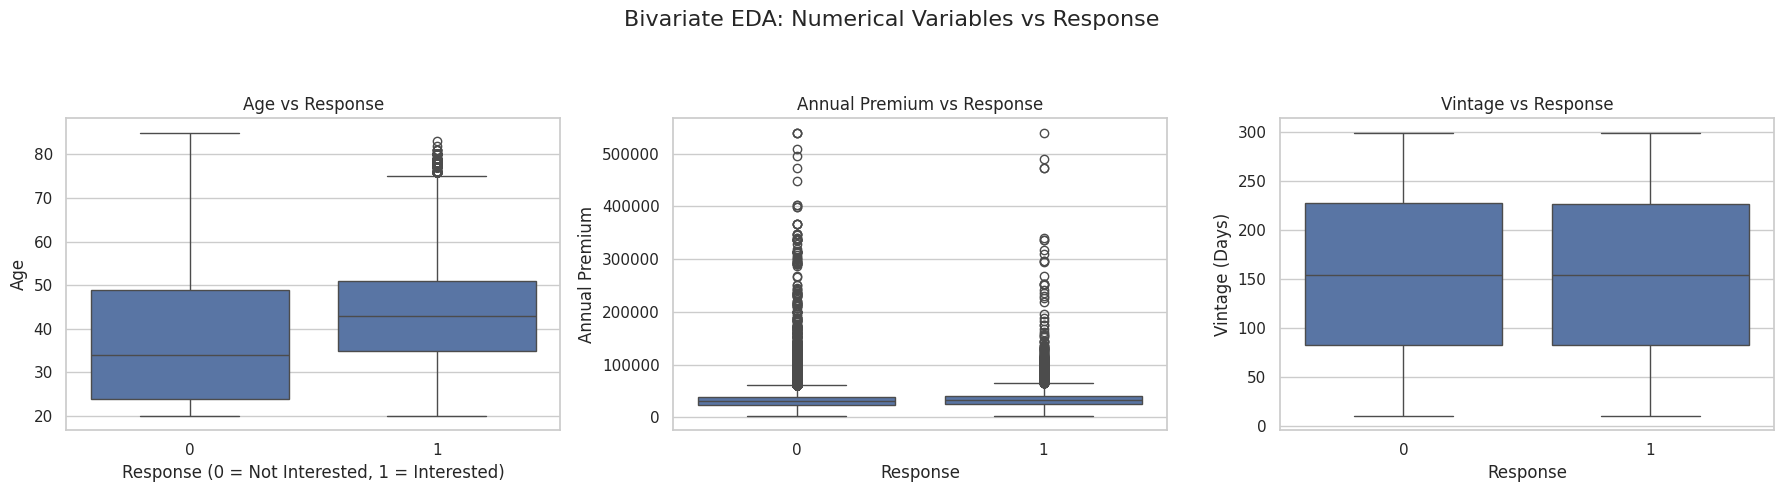

✅ Saved: eda_bivariate_numerical_response.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# โหลดข้อมูล
df = pd.read_excel("train.xlsx")

# เตรียม figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Bivariate EDA: Numerical Variables vs Response",
    fontsize=16
)

# 1. Age vs Response
sns.boxplot(
    data=df,
    x="Response",
    y="Age",
    ax=axes[0]
)
axes[0].set_title("Age vs Response")
axes[0].set_xlabel("Response (0 = Not Interested, 1 = Interested)")
axes[0].set_ylabel("Age")

# 2. Annual Premium vs Response
sns.boxplot(
    data=df,
    x="Response",
    y="Annual_Premium",
    ax=axes[1]
)
axes[1].set_title("Annual Premium vs Response")
axes[1].set_xlabel("Response")
axes[1].set_ylabel("Annual Premium")

# 3. Vintage vs Response
sns.boxplot(
    data=df,
    x="Response",
    y="Vintage",
    ax=axes[2]
)
axes[2].set_title("Vintage vs Response")
axes[2].set_xlabel("Response")
axes[2].set_ylabel("Vintage (Days)")

# layout + save
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(
    "eda_bivariate_numerical_response.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Saved: eda_bivariate_numerical_response.png")

# EDA-Others

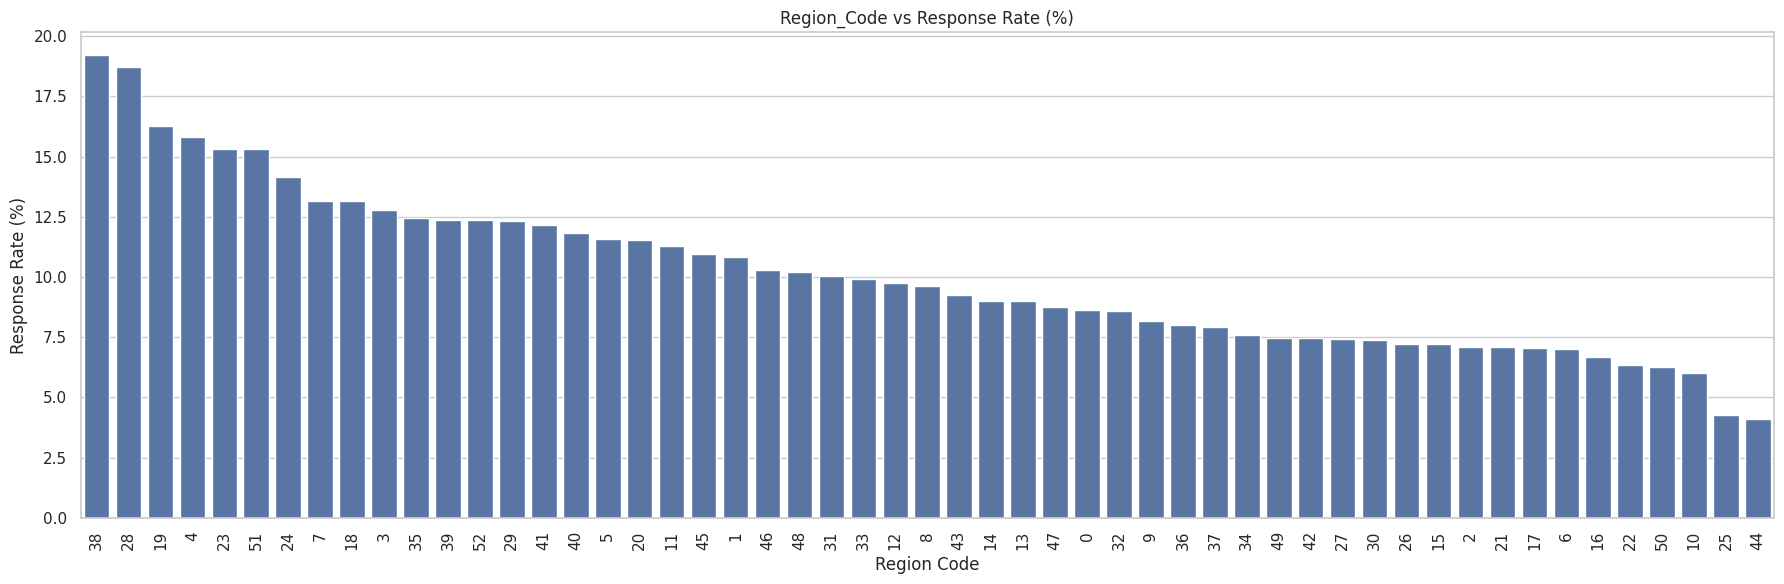

✅ Sorted by Response Rate (High → Low)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_excel("train.xlsx")

# Compute response rate
region_rr = (
    df.groupby("Region_Code")["Response"]
    .mean()
    .mul(100)
    .reset_index(name="Response Rate (%)")
)

# ✅ สร้าง order จาก Response Rate (มาก → น้อย)
order_rr = region_rr.sort_values(
    "Response Rate (%)", ascending=False
)["Region_Code"]

# Plot
plt.figure(figsize=(18, 6))
sns.barplot(
    data=region_rr,
    x="Region_Code",
    y="Response Rate (%)",
    order=order_rr        # 🔴 จุดแก้ไขสำคัญ
)

plt.title("Region_Code vs Response Rate (%)")
plt.xlabel("Region Code")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(
    "eda_region_response_rate_sorted_by_rr.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Sorted by Response Rate (High → Low)")

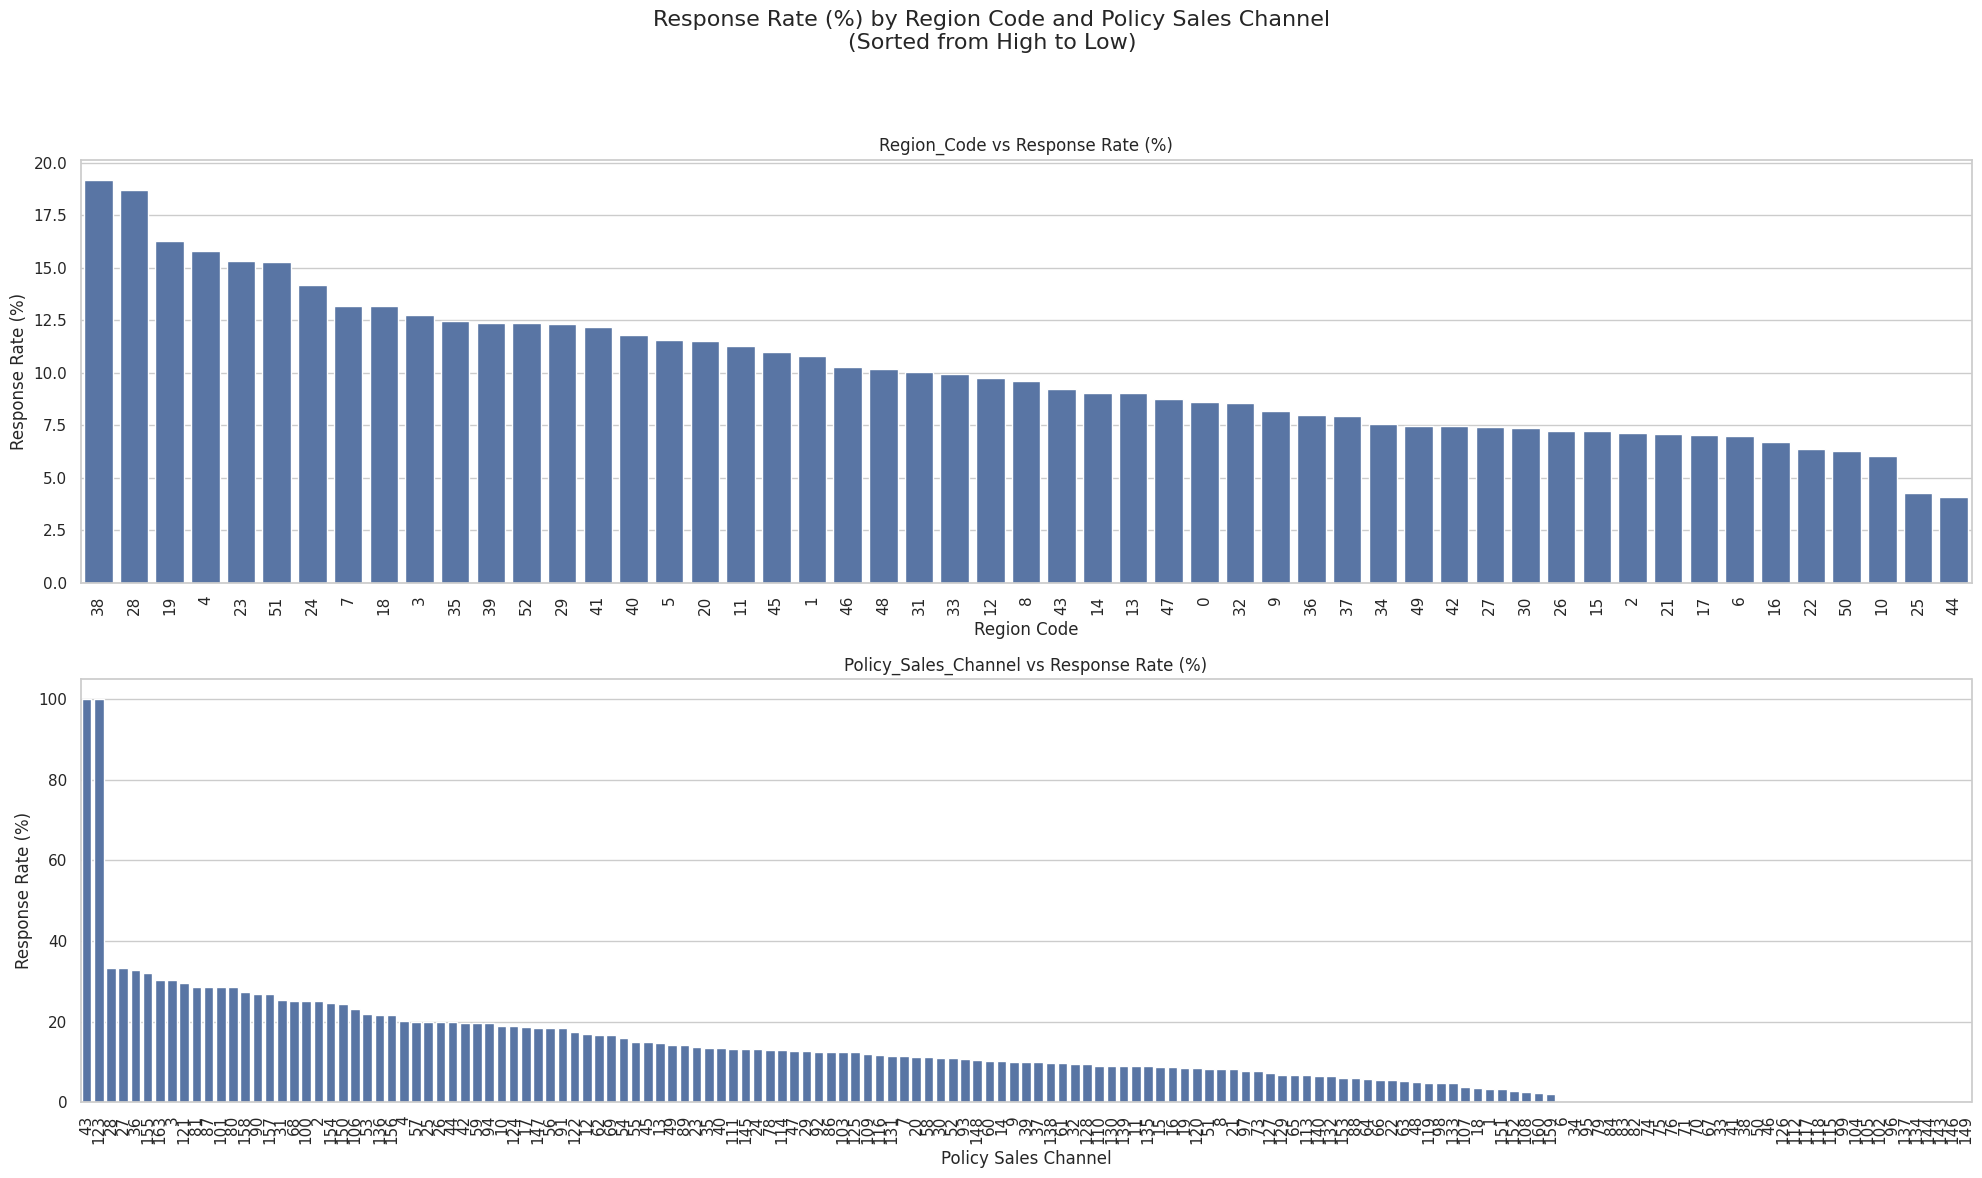

✅ Saved: eda_region_and_channel_response_rate_sorted.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# Load data
# =========================
df = pd.read_excel("train.xlsx")

# =========================
# 1) Region_Code Response Rate
# =========================
region_rr = (
    df.groupby("Region_Code")["Response"]
    .mean()
    .mul(100)
    .reset_index(name="Response Rate (%)")
)

region_order = region_rr.sort_values(
    "Response Rate (%)", ascending=False
)["Region_Code"]

# =========================
# 2) Policy_Sales_Channel Response Rate
# =========================
channel_rr = (
    df.groupby("Policy_Sales_Channel")["Response"]
    .mean()
    .mul(100)
    .reset_index(name="Response Rate (%)")
)

channel_order = channel_rr.sort_values(
    "Response Rate (%)", ascending=False
)["Policy_Sales_Channel"]

# =========================
# Plot: One figure (Top-Bottom)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharey=False)
fig.suptitle(
    "Response Rate (%) by Region Code and Policy Sales Channel\n"
    "(Sorted from High to Low)",
    fontsize=16
)

# ---- Top: Region_Code ----
sns.barplot(
    data=region_rr,
    x="Region_Code",
    y="Response Rate (%)",
    order=region_order,
    ax=axes[0]
)
axes[0].set_title("Region_Code vs Response Rate (%)")
axes[0].set_xlabel("Region Code")
axes[0].set_ylabel("Response Rate (%)")
axes[0].tick_params(axis="x", rotation=90)

# ---- Bottom: Policy_Sales_Channel ----
sns.barplot(
    data=channel_rr,
    x="Policy_Sales_Channel",
    y="Response Rate (%)",
    order=channel_order,
    ax=axes[1]
)
axes[1].set_title("Policy_Sales_Channel vs Response Rate (%)")
axes[1].set_xlabel("Policy Sales Channel")
axes[1].set_ylabel("Response Rate (%)")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(
    "eda_region_and_channel_response_rate_sorted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Saved: eda_region_and_channel_response_rate_sorted.png")

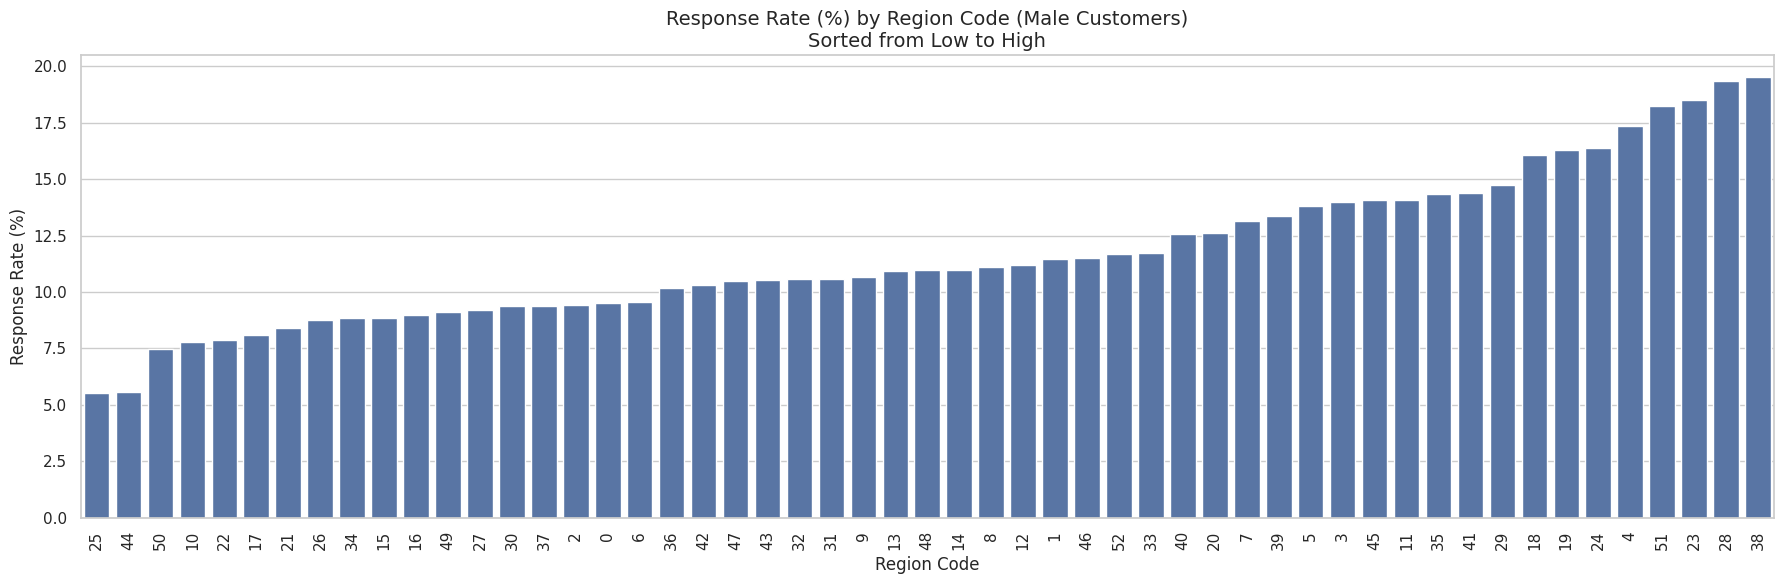

✅ Saved: eda_region_response_rate_male_sorted_low_to_high.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ---------------------------
# Load data
# ---------------------------
df = pd.read_excel("train.xlsx")

# ---------------------------
# Filter: Male only
# ---------------------------
df_male = df[df["Gender"] == "Male"]

# ---------------------------
# Compute response rate by Region_Code (Male only)
# ---------------------------
region_rr_male = (
    df_male.groupby("Region_Code")["Response"]
    .mean()
    .mul(100)
    .reset_index(name="Response Rate (%)")
)

# ---------------------------
# Define order: sort by Response Rate (Low → High)
# ---------------------------
order_rr = region_rr_male.sort_values(
    "Response Rate (%)", ascending=True
)["Region_Code"]

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(18, 6))
sns.barplot(
    data=region_rr_male,
    x="Region_Code",
    y="Response Rate (%)",
    order=order_rr          # 🔴 สำคัญ: บังคับเรียงตาม Y
)

plt.title(
    "Response Rate (%) by Region Code (Male Customers)\nSorted from Low to High",
    fontsize=14
)
plt.xlabel("Region Code")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(
    "eda_region_response_rate_male_sorted_low_to_high.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Saved: eda_region_response_rate_male_sorted_low_to_high.png")

# EDA-Heatmap

In [ ]:
# เลือกเฉพาะ numeric features
num_features = [
    'Age',
    'Driving_License',
    'Previously_Insured',
    'Annual_Premium',
    'Vintage',
    'Response'
]

corr_df = df[num_features]

In [ ]:
corr_matrix = corr_df.corr()
corr_matrix

,Age,Driving_License,Previously_Insured,Annual_Premium,Vintage,Response
Age,1.000000,-0.079782,-0.254682,0.067507,-0.001264,0.111147
Driving_License,-0.079782,1.000000,0.014969,-0.011906,-0.000848,0.010155
Previously_Insured,-0.254682,0.014969,1.000000,0.004269,0.002537,-0.341170
Annual_Premium,0.067507,-0.011906,0.004269,1.000000,-0.000608,0.022575
Vintage,-0.001264,-0.000848,0.002537,-0.000608,1.000000,-0.001050
Response,0.111147,0.010155,-0.341170,0.022575,-0.001050,1.000000


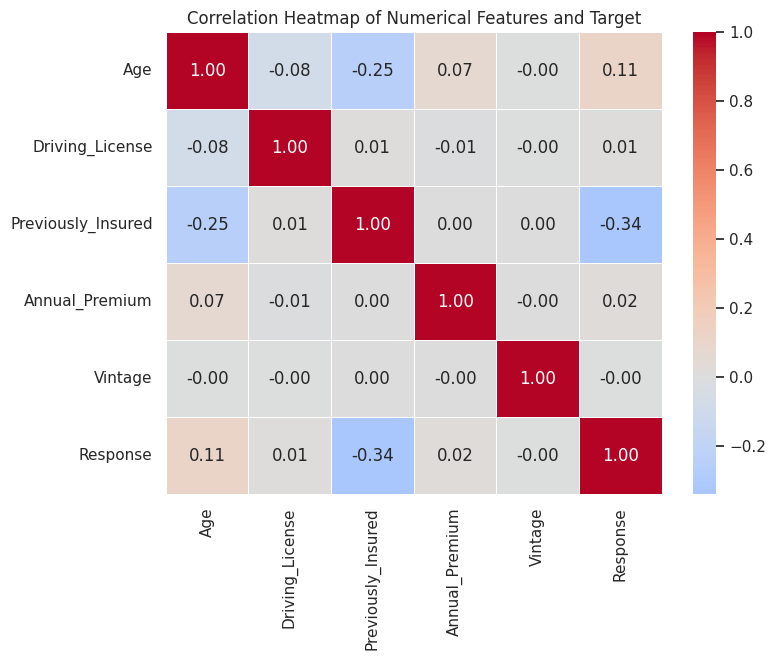

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features and Target")
plt.show()

# Other

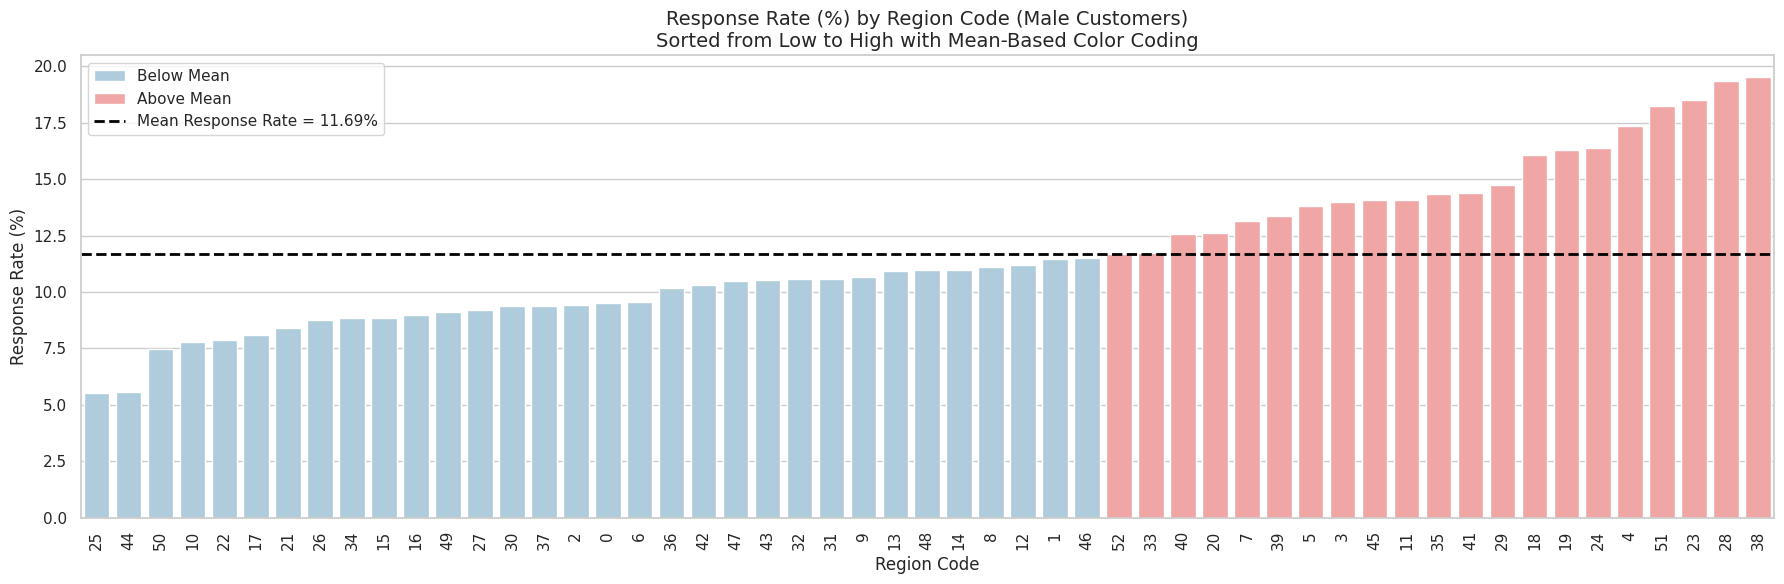

✅ Saved: eda_region_response_rate_male_color_by_mean.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------------------------------
# Load data
# -------------------------------------------------
df = pd.read_excel("train.xlsx")

# -------------------------------------------------
# Filter: Male only
# -------------------------------------------------
df_male = df[df["Gender"] == "Male"]

# -------------------------------------------------
# Compute response rate by Region_Code
# -------------------------------------------------
region_rr_male = (
    df_male.groupby("Region_Code")["Response"]
    .mean()
    .mul(100)
    .reset_index(name="Response Rate (%)")
)

# -------------------------------------------------
# Compute mean response rate
# -------------------------------------------------
mean_rr = region_rr_male["Response Rate (%)"].mean()

# -------------------------------------------------
# Create flag: Above / Below mean
# -------------------------------------------------
region_rr_male["Mean_Group"] = region_rr_male["Response Rate (%)"].apply(
    lambda x: "Above Mean" if x > mean_rr else "Below Mean"
)

# -------------------------------------------------
# Sort order: Low → High response rate
# -------------------------------------------------
order_rr = region_rr_male.sort_values(
    "Response Rate (%)", ascending=True
)["Region_Code"]

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(18, 6))

sns.barplot(
    data=region_rr_male,
    x="Region_Code",
    y="Response Rate (%)",
    order=order_rr,
    hue="Mean_Group",
    palette={
        "Below Mean": "#A6CEE3",   # ฟ้าอ่อน
        "Above Mean": "#FB9A99"    # แดงอ่อน
    }
)

# Mean line
plt.axhline(
    y=mean_rr,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean Response Rate = {mean_rr:.2f}%"
)

plt.title(
    "Response Rate (%) by Region Code (Male Customers)\n"
    "Sorted from Low to High with Mean-Based Color Coding",
    fontsize=14
)
plt.xlabel("Region Code")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=90)

plt.legend()
plt.tight_layout()
plt.savefig(
    "eda_region_response_rate_male_color_by_mean.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("✅ Saved: eda_region_response_rate_male_color_by_mean.png")